# Customer Behaviour: with RFM Analysis

## Introduction

In today's competitive business, it is vital to understand the long-term value of a customer. 
Customer Lifetime Value (CLTV) is a metric that represents the total amount of money a customer is expected to spend in your business or your products during their lifetime.
It's a crucial measure that helps businesses in strategizing their marketing efforts, resource allocation and product development.


**IMPORTANCE OF CLTV:**
* **Resource Allocation:** It helps in allocatingresources more efficiently. Instead of spreading resources over all customers, businesses can focus on those who bring in the most value.

* **Product Development and Pricing Strategies:** Understanding the lifetime value of a customer can influence product development strategies. Businesses can design products and services nthat cater to the needs of their most profitable customers. It also helps in setting pricing strategies that maximize profit without losing valuable customers.

* **Predictive Analysis:** It helps in forecasting future revenues and making informed decisions about potential investments in customer acquisition and retention.

* **Focused Marketing and Customer retention:** It enables businesses to identify the most valuable customers, allowing for more targeted and personalized marketing strategies. By understanding who your high-value customers are, you can tailor your marketing efforts to retain these profitable segments.

## Overview of RFM Analysis

RFM(RECENCY, FREQUENCY, MONETARY) Analysis is a marketing technique used for quantifying and evaluating customer behaviour. It segments customers based on their tranaction history - how recently and how often they purchased, and how much they spent.


* **Recency(R):** This is the measure of how recently a customer has made a purchase. A recent purchase is a strong indicator that the customer is active and more likely to buy again.


* **Frequency(F):** This accesses how often a customer makes a purchase. Frequent buyers are more likely to continue purchasing in the future, indicating higher loyalty, satisfaction and engagement. While infrequent purchases suggests a need for re-engagement strategies.


* **Monetary Value(M):** This evaluates how much money a customer has spent over time. Customers who spend more are the valuable. This determines the customer's value to the business. High monetary customers contribute more to revenue, while lower spenders may require targeted strategies to increase their purchasing activity.


To successfully perform RFM, our dataset must have some crucial features:

* **Customer Identifier:** A unique identifier for each customer to differentiate between customers and aggregate purchases on a per-customer basis.

* **Transaction/Purchase Date:** Date and time the purchases were made to calculate the Recency component of RFM.

* **Transaction Value:** The monetary value of each transaction to compute the Monetary component of RFM, which is total amount spent by the customer.

* **Transaction Frequency (Optional):** Information on the frequency of transactions. It can as well be done by counting the number of transactions per customer.

## IMPORTANCE OF RFM IN BUSINESS STRATEGIES

By integrating RFM analysis into business strategies, companies can:

* **Optimize Marketing Campaigns:** RFM analysis can drive more effective marketing campaigns by targeting the right customers with the right message at the right time.

* **Improve Customer Service:** Understanding different segments helps in tailoring customer service efforts to meet the specific needs and preferences of each group.

* **Increase Customer Loyalty:** By focusing on customers who are more likely to make frequent and recent purchases, businesses can implement strategies to boost customer loyalty.

* **Identify Potential High-Value Customers:** It helps in spotting customers with the potential to become high-value patrons based on their buying patterns.

* **Personalized Customer Engagement:** It gives room for more personalized communications and offers, as customers are segmented based on their purchasing behaviour.


It is a great tool for business aiming to thrive in a customer-centric era. It helps in serving current customers and also in predicting and shaping future customer interactions and profitability.

## Main Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ====================
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
retail_df = pd.read_csv(
    "/home/tongxin_wang/projects/Wendy_files/online_retail.csv")

retail_df.head(6)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom


In [3]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [4]:
retail_df.shape

(541909, 8)

In [5]:
retail_df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### EXPLORATORY DATA ANALYSIS

In [6]:
# Remove duplicates
retail_df.drop_duplicates(inplace=True)

# Drop the missing values
retail_df.dropna(subset=["CustomerID"], inplace=True)

In [7]:
# Create a "Total" column
retail_df["Total"] = retail_df["Quantity"] * retail_df["UnitPrice"]
retail_df["Total"].head(6)

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
5    15.30
Name: Total, dtype: float64

In [8]:
# Check the max date
retail_df["InvoiceDate"].max()

'2011-12-09 12:50:00'

### Calculating RFM Metrics 

In [9]:
import datetime as dt

# Recency
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])
latest_date = retail_df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = retail_df.groupby('CustomerID').agg({
    "InvoiceDate": lambda x: (latest_date - x.max()).days,
    "InvoiceNo": "count",
    "Total": "sum"
}).reset_index()

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "Total": "MonetaryValue"
}, inplace=True)

In [10]:
# Recency score based on quantiles
# Assigning labels from 1-5, 1 being the lowest recency
rfm["Recency_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])

# Frequency score
rfm["Frequency_Score"] = pd.qcut(rfm["Frequency"].rank(
    method="first"), 5, labels=[5, 4, 3, 2, 1])

In [11]:
# Combine Recency and Frequency scores to create the RFM Segment
rfm["rfm_segment"] = rfm["Recency_Score"].astype(
    str) + rfm["Frequency_Score"].astype(str)

# Final Check
rfm

,CustomerID,Recency,Frequency,MonetaryValue,Recency_Score,Frequency_Score,rfm_segment
0,12346.0,326,2,0.00,1,5,15
1,12347.0,2,182,4310.00,5,1,51
2,12348.0,75,31,1797.24,2,3,23
3,12349.0,19,73,1757.55,4,2,42
4,12350.0,310,17,334.40,1,4,14
...,...,...,...,...,...,...,...
4367,18280.0,278,10,180.60,1,5,15
4368,18281.0,181,7,80.82,1,5,15
4369,18282.0,8,13,176.60,5,5,55
4370,18283.0,4,721,2045.53,5,1,51


## Data Visualization

### Recency Distribution

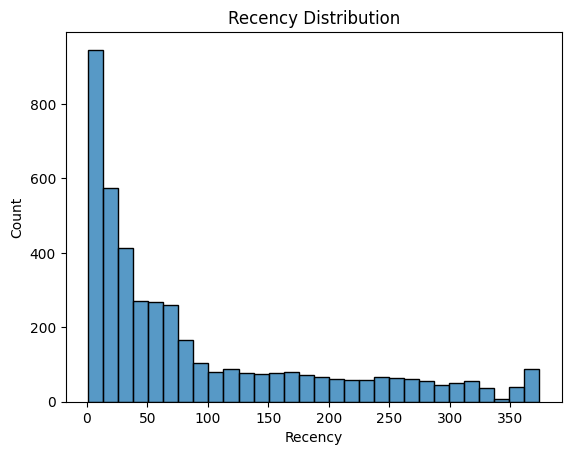

In [12]:
sns.histplot(data=rfm, x="Recency", bins=30)
plt.title("Recency Distribution")
plt.show()

### Frequency Distribution

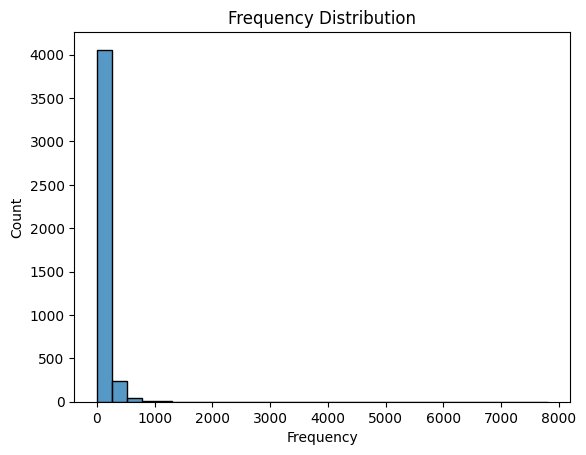

In [13]:
sns.histplot(data=rfm, x="Frequency", bins=30)
plt.title('Frequency Distribution')
plt.show()

### Monetary Distribution 

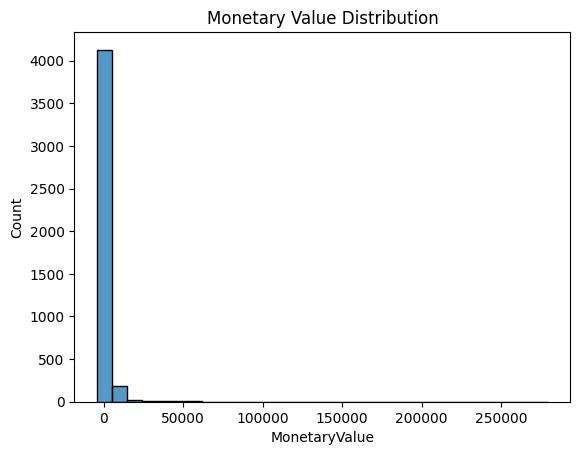

In [14]:
sns.histplot(data=rfm, x="MonetaryValue", bins=30)
plt.title("Monetary Value Distribution")
plt.show()

## Customer Segmentation

In [15]:
# Mapping segments to their corresponding customer segments
segment_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At-Risk',
    r'[1-2]5': "Can\'t Loose",
    r'3[1-2]': 'About to Slip',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions',
}

# Mapping RFM segments to corresponding customer segments
rfm['rfm_segment'] = rfm['rfm_segment'].replace(segment_map, regex=True)

rfm

,CustomerID,Recency,Frequency,MonetaryValue,Recency_Score,Frequency_Score,rfm_segment
0,12346.0,326,2,0.00,1,5,Can't Loose
1,12347.0,2,182,4310.00,5,1,New Customers
2,12348.0,75,31,1797.24,2,3,At-Risk
3,12349.0,19,73,1757.55,4,2,Potential Loyalists
4,12350.0,310,17,334.40,1,4,At-Risk
...,...,...,...,...,...,...,...
4367,18280.0,278,10,180.60,1,5,Can't Loose
4368,18281.0,181,7,80.82,1,5,Can't Loose
4369,18282.0,8,13,176.60,5,5,Champions
4370,18283.0,4,721,2045.53,5,1,New Customers


## Data Standardization

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'MonetaryValue']])

rfm_scaled

array([[ 2.32202285, -0.39205597, -0.23041952],
       [-0.89373323,  0.39329343,  0.29405454],
       [-0.1691956 , -0.26552745, -0.01171748],
       ...,
       [-0.83418219, -0.34406239, -0.20892947],
       [-0.87388289,  2.74497857,  0.01849636],
       [-0.48680114, -0.09536842, -0.00684511]], shape=(4372, 3))

## KMeans Clustering

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(rfm_scaled)
rfm['Cluster'] = kmeans.labels_

We will categorize the customers based on their RFM values into groups such as **"Loyal Customers"**, **"New Customers"**, **"At-Risk Customers"** and **"Lost Customers"**.

* **Champions:** Bought recently, buy often and spend the most.

* **Loyal Customers (High Frequency, Low Recency, High Monetary):** These customers buy often and spend a lot. They are recent buyers, indicating ongoing engagement.

* **Potential Loyalist:** Recent customers but spent a good amount and bought more than once.

* **Recent Customers:** Bought most recently but not often.

* **Promising:** Recent buyers but haven't spent much.

* **Customers Needing Attention:** Above average recency, frequency and monetary values. May not have bought very recently though.

* **About to Slip:** Below average recency, frequency and monetary values. Will lose them if not reactivated.

* **New Customers (Low Frequency, Low Recency, Low/Medium Monetary):** These are customers who have started buying recently but have not yet bought frequently or spent a lot.


* **At-Risk Customers (Low Frequency, High Recency, Medium/High Monetary):** These are customers who used to buy frequently and spend a significant amount, but it's been long time they purchased.

* **Lost Customers (Low Frequency, High Recency, Low Monetary):** These customers have not purchased in a long time, they seldom bought and when they do, they spend little.

* **Can't Lose Them:** Made biggest purchases and often. But haven't returned for a long time.

* **Hibernating:** Last purchases was long back, with low spenders and low number of orders.

In [18]:
rfm.head(10)

,CustomerID,Recency,Frequency,MonetaryValue,Recency_Score,Frequency_Score,rfm_segment,Cluster
0,12346.0,326,2,0.00,1,5,Can't Loose,1
1,12347.0,2,182,4310.00,5,1,New Customers,0
2,12348.0,75,31,1797.24,2,3,At-Risk,0
3,12349.0,19,73,1757.55,4,2,Potential Loyalists,0
4,12350.0,310,17,334.40,1,4,At-Risk,1
5,12352.0,36,95,1545.41,3,2,About to Slip,0
6,12353.0,204,4,89.00,1,5,Can't Loose,1
7,12354.0,232,58,1079.40,1,3,At-Risk,1
8,12355.0,214,13,459.40,1,5,Can't Loose,1
9,12356.0,23,59,2811.43,4,2,Potential Loyalists,0


In [19]:
new_rfm = rfm[["Recency", "Frequency", "MonetaryValue", "rfm_segment"]]
new_rfm

,Recency,Frequency,MonetaryValue,rfm_segment
0,326,2,0.00,Can't Loose
1,2,182,4310.00,New Customers
2,75,31,1797.24,At-Risk
3,19,73,1757.55,Potential Loyalists
4,310,17,334.40,At-Risk
...,...,...,...,...
4367,278,10,180.60,Can't Loose
4368,181,7,80.82,Can't Loose
4369,8,13,176.60,Champions
4370,4,721,2045.53,New Customers


In [20]:
new_rfm.index = new_rfm.index.astype(int)
new_rfm.head()

,Recency,Frequency,MonetaryValue,rfm_segment
0,326,2,0.00,Can't Loose
1,2,182,4310.00,New Customers
2,75,31,1797.24,At-Risk
3,19,73,1757.55,Potential Loyalists
4,310,17,334.40,At-Risk


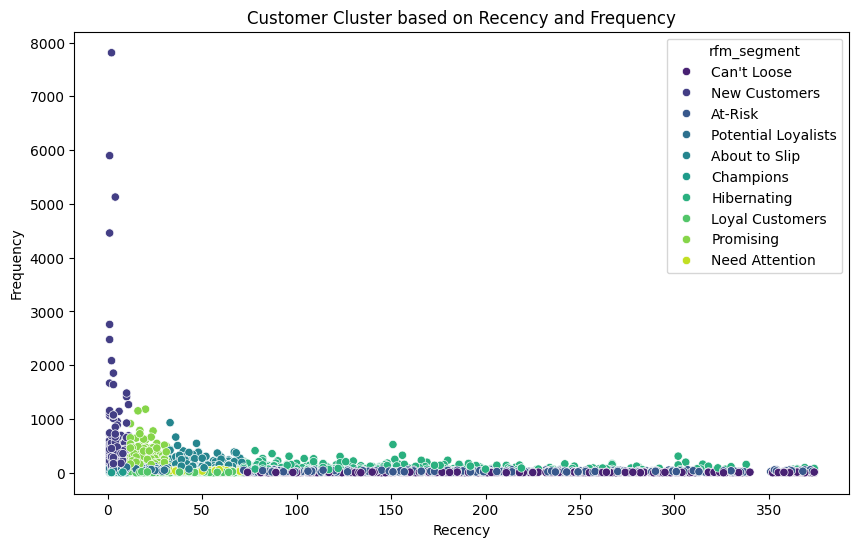

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=new_rfm,
    x='Recency', y='Frequency',
    hue='rfm_segment', palette='viridis'
)
plt.title('Customer Cluster based on Recency and Frequency')
plt.show()

In [22]:
# Top 10 most preferred products
segments = new_rfm['rfm_segment'].value_counts()

fig = px.bar(
    x=segments.index,
    y=segments.values,
    color=segments.index,
    text=segments.values,
    title="RFM Segments"
)
fig.update_layout(
    xaxis_title="Segment",
    yaxis_title="Count",
    font=dict(size=15, family="Arial"),
    title_font=dict(size=20, family="Arial")
)
fig.show()

In [23]:
# Customer Segments Distribution
EXPLODE = (0.1,0,0,0,0,0,0,0,0,0)

fig = px.pie(
    values=segments.values,
    names=segments.index,
    title="Customer Segments Distribution",
    color=segments.index,
    color_discrete_sequence=px.colors.qualitative.Pastel,
    width=600, height=500
)

fig.update_traces(
    textinfo='percent+label',
    pull=EXPLODE,
)

fig.show()

In [24]:
# Customer Segments by Frequency
fig = px.bar(
    new_rfm,
    x="rfm_segment",
    y="Frequency",
    title="Customer Segments by Frequency",
    color="rfm_segment",
    color_discrete_sequence=px.colors.qualitative.Dark24
)

fig.update_layout(
    xaxis_title="Segment",
    yaxis_title="Frequency",
    xaxis_tickangle=45,
    width=900,
    height=500
)

fig.show()

In [25]:
new_rfm[["rfm_segment","Recency", "Frequency", "MonetaryValue"]].groupby("rfm_segment").agg(["mean", "count","sum"])

Recency                 Frequency                \
                           mean count     sum        mean count     sum   
rfm_segment                                                               
About to Slip         48.597015   335   16280  139.510448   335   46736   
At-Risk              189.053676   857  162019   29.421237   857   25214   
Can't Loose          221.666667   573  127015    6.834206   573    3916   
Champions              6.547445   137     897   15.459854   137    2118   
Hibernating          148.803279   305   45385  107.744262   305   32862   
Loyal Customers       39.981685   546   21830   15.512821   546    8470   
Need Attention        51.213930   201   10294   41.079602   201    8257   
New Customers          4.984925   398    1984  389.919598   398  155188   
Potential Loyalists   14.822686   767   11369   69.080834   767   52985   
Promising             21.173913   253    5357  260.308300   253   65858   

                    MonetaryValue                     
                             mean count          sum  
rfm_segment                                           
About to Slip         2134.437194   335   715036.460  
At-Risk                603.270994   857   517003.242  
Can't Loose            256.620244   573   147043.400  
Champions              649.330584   137    88958.290  
Hibernating           1558.580331   305   475367.001  
Loyal Customers        430.975659   546   235312.710  
Need Attention         799.003985   201   160599.801  
New Customers         9204.469598   398  3663378.900  
Potential Loyalists   1612.248970   767  1236594.960  
Promising             4107.607352   253  1039224.660

## Prediction

### Predicting Future Customer Spending

In [26]:
features = rfm[['Recency', 'Frequency', 'MonetaryValue']]

In [27]:
# Creating a dummy target variable 
rfm['FutureSpending'] = np.random.rand(len(rfm)) * 3000

rfm

,CustomerID,Recency,Frequency,MonetaryValue,Recency_Score,Frequency_Score,rfm_segment,Cluster,FutureSpending
0,12346.0,326,2,0.00,1,5,Can't Loose,1,2455.661475
1,12347.0,2,182,4310.00,5,1,New Customers,0,1666.313647
2,12348.0,75,31,1797.24,2,3,At-Risk,0,848.216003
3,12349.0,19,73,1757.55,4,2,Potential Loyalists,0,1262.922980
4,12350.0,310,17,334.40,1,4,At-Risk,1,984.055122
...,...,...,...,...,...,...,...,...,...
4367,18280.0,278,10,180.60,1,5,Can't Loose,1,28.985098
4368,18281.0,181,7,80.82,1,5,Can't Loose,1,134.455215
4369,18282.0,8,13,176.60,5,5,Champions,0,2075.784850
4370,18283.0,4,721,2045.53,5,1,New Customers,0,714.076807


In [28]:
# Splitting the dataset 
from sklearn.model_selection import train_test_split

X = features
y = rfm['FutureSpending']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Linear Regression

In [29]:
# Linear Regression Modelling 
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
# Evaluating the model 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pred = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"The mean absoute error is: {mae}")
print(f"The mean squared error is: {mse}")
print(f"The r2 score is: {r2}")

The mean absoute error is: 749.4861687492303
The mean squared error is: 746236.0111123878
The r2 score is: -0.0011000398462936989


In [31]:
results_df = pd.DataFrame({'Future Spending': y_test, 'Predicted Spending': pred})
results_df

,Future Spending,Predicted Spending
2014,2713.731371,1482.946699
457,224.442630,1500.074377
478,129.079085,1470.762449
438,384.675200,1509.165347
3728,2184.052277,1508.775084
...,...,...
733,1961.123972,1509.969708
56,1106.817276,1512.395321
2323,1070.724452,1507.436093
1720,2417.712269,1518.407630


## Decision Tree Regressor

In [32]:
from sklearn.tree import DecisionTreeRegressor

dec_tree = DecisionTreeRegressor()
dec_tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [33]:
# Evaluation of the model
dec_tree_pred = dec_tree.predict(X_test)

mae = mean_absolute_error(y_test, dec_tree_pred)
mse = mean_squared_error(y_test, dec_tree_pred)
r2 = r2_score(y_test, dec_tree_pred)

print(f"The mean absoute error is: {mae}")
print(f"The mean squared error is: {mse}")
print(f"The r2 score is: {r2}")

The mean absoute error is: 998.6129985320617
The mean squared error is: 1496373.8334244983
The r2 score is: -1.007434487157985


In [34]:
results_df = pd.DataFrame({'Future Spending': y_test, 'Predicted Spending': dec_tree_pred})
results_df

,Future Spending,Predicted Spending
2014,2713.731371,1579.088255
457,224.442630,1367.455290
478,129.079085,1611.754960
438,384.675200,672.326948
3728,2184.052277,1291.878306
...,...,...
733,1961.123972,724.255670
56,1106.817276,849.409570
2323,1070.724452,165.550113
1720,2417.712269,2921.229422


## Future Predictions

In [35]:
new_customer_rfm = np.array([[10, 5, 300]])
pred_spending = lin_reg.predict(new_customer_rfm)

print(f"Predicted Future Spending: {pred_spending[0]}")

Predicted Future Spending: 1508.198836780244


/home/tongxin_wang/miniconda3/envs/wende/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Analysis Report

* We were able to segment customers based on their recency, frequency and monetary value.

* We were able to detect our most valuable customers.

* We were able to detect our loyal customers.

* We were able to detect our new customers.

* We were able to detect our lost customers, so we will probably find out why they left us and how to regain their loyalties.

* We were able to develop a model for predicting future customer spending based on RFM analysis.

## Conclusion

* RFM Analysis is a crucial tool for understanding customer behaviour and segmenting them based on purchasing habits.

* RFM helps in personalizing marketing strategies and improving customer engagement and retention.